# **Model Training (Multiclass Classification)** #



# Load Full Dataset (Multiclass)

In [3]:
import joblib

Xm_train, Xm_test, ym_train, ym_test = joblib.load(
    "../data/processed/multiclass_dataset.pkl"
)

print(ym_train.value_counts())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xm_train = scaler.fit_transform(Xm_train)
Xm_test = scaler.transform(Xm_test)

Failure Type
PWF                 6611
HDF                 6203
OSF                 6175
TWF                 5982
Multiple Failure    5619
RNF                 4991
No Failure          3285
Name: count, dtype: int64


# Create Multiclass Evaluation Function

In [4]:
def evaluate_multiclass(y_true, y_pred):
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted")
    }
    
    report = classification_report(y_true, y_pred)
    
    return metrics, report

# Train & Evaluate All Models

1. Logistic Regression

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [6]:
def get_logistic_multi():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        ))
    ])

In [7]:
log_m = get_logistic_multi()
log_m.fit(Xm_train, ym_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [8]:
log_pred = log_m.predict(Xm_test)

In [9]:
log_metrics = {
    "accuracy": accuracy_score(ym_test, log_pred),
    "macro_f1": f1_score(ym_test, log_pred, average="macro"),
    "weighted_f1": f1_score(ym_test, log_pred, average="weighted")
}

print("Logistic Regression - Multiclass Metrics")
print(log_metrics)

print("\nClassification Report:")
print(classification_report(ym_test, log_pred))

Logistic Regression - Multiclass Metrics
{'accuracy': 0.603, 'macro_f1': 0.32653789128497906, 'weighted_f1': 0.7297081787188363}

Classification Report:
                  precision    recall  f1-score   support

             HDF       0.22      0.94      0.36        32
Multiple Failure       0.21      0.71      0.32         7
      No Failure       1.00      0.59      0.74      2896
             OSF       0.26      0.78      0.39        23
             PWF       0.23      0.92      0.37        24
             RNF       0.00      0.20      0.00         5
             TWF       0.05      1.00      0.10        13

        accuracy                           0.60      3000
       macro avg       0.28      0.73      0.33      3000
    weighted avg       0.97      0.60      0.73      3000



2. Decision Tree (Multiclass)

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [11]:
def get_tree_multi():
    return DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    )

In [12]:
tree_m = get_tree_multi()
tree_m.fit(Xm_train, ym_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [13]:
tree_pred = tree_m.predict(Xm_test)

In [14]:
tree_metrics = {
    "accuracy": accuracy_score(ym_test, tree_pred),
    "macro_f1": f1_score(ym_test, tree_pred, average="macro"),
    "weighted_f1": f1_score(ym_test, tree_pred, average="weighted")
}

print("Decision Tree - Multiclass Metrics")
print(tree_metrics)

print("\nClassification Report:")
print(classification_report(ym_test, tree_pred))

Decision Tree - Multiclass Metrics
{'accuracy': 0.903, 'macro_f1': 0.49619348688352344, 'weighted_f1': 0.9357382500131469}

Classification Report:
                  precision    recall  f1-score   support

             HDF       0.58      0.91      0.71        32
Multiple Failure       0.25      0.57      0.35         7
      No Failure       0.99      0.91      0.95      2896
             OSF       0.32      0.83      0.46        23
             PWF       0.91      0.88      0.89        24
             RNF       0.00      0.00      0.00         5
             TWF       0.07      0.46      0.12        13

        accuracy                           0.90      3000
       macro avg       0.45      0.65      0.50      3000
    weighted avg       0.98      0.90      0.94      3000



3. Random Forest (Multiclass)

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [16]:
def get_rf_multi():
    return RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

In [17]:
rf_m = get_rf_multi()
rf_m.fit(Xm_train, ym_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
rf_pred = rf_m.predict(Xm_test)

In [19]:
rf_metrics = {
    "accuracy": accuracy_score(ym_test, rf_pred),
    "macro_f1": f1_score(ym_test, rf_pred, average="macro"),
    "weighted_f1": f1_score(ym_test, rf_pred, average="weighted")
}

print("Random Forest - Multiclass Metrics")
print(rf_metrics)

print("\nClassification Report:")
print(classification_report(ym_test, rf_pred))

Random Forest - Multiclass Metrics
{'accuracy': 0.9256666666666666, 'macro_f1': 0.5686948086400371, 'weighted_f1': 0.9500887348744841}

Classification Report:
                  precision    recall  f1-score   support

             HDF       0.80      1.00      0.89        32
Multiple Failure       0.46      0.86      0.60         7
      No Failure       1.00      0.93      0.96      2896
             OSF       0.32      0.87      0.47        23
             PWF       0.92      0.96      0.94        24
             RNF       0.00      0.00      0.00         5
             TWF       0.07      0.54      0.12        13

        accuracy                           0.93      3000
       macro avg       0.51      0.74      0.57      3000
    weighted avg       0.98      0.93      0.95      3000



4. SVM (Multiclass)

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [21]:
def get_svm_multi():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced"
        ))
    ])

In [22]:
svm_m = get_svm_multi()
svm_m.fit(Xm_train, ym_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [23]:
svm_pred = svm_m.predict(Xm_test)

In [24]:
svm_metrics = {
    "accuracy": accuracy_score(ym_test, svm_pred),
    "macro_f1": f1_score(ym_test, svm_pred, average="macro"),
    "weighted_f1": f1_score(ym_test, svm_pred, average="weighted")
}

print("SVM - Multiclass Metrics")
print(svm_metrics)

print("\nClassification Report:")
print(classification_report(ym_test, svm_pred))

SVM - Multiclass Metrics
{'accuracy': 0.8243333333333334, 'macro_f1': 0.43364068464368016, 'weighted_f1': 0.884774138425606}

Classification Report:
                  precision    recall  f1-score   support

             HDF       0.32      1.00      0.48        32
Multiple Failure       0.46      0.86      0.60         7
      No Failure       0.99      0.82      0.90      2896
             OSF       0.32      0.96      0.48        23
             PWF       0.35      0.75      0.48        24
             RNF       0.00      0.20      0.01         5
             TWF       0.05      0.54      0.09        13

        accuracy                           0.82      3000
       macro avg       0.36      0.73      0.43      3000
    weighted avg       0.97      0.82      0.88      3000



# Comparison Table

In [25]:
import pandas as pd

results_multi = {
    "Logistic Regression": log_metrics,
    "Decision Tree": tree_metrics,
    "Random Forest": rf_metrics,
    "SVM": svm_metrics
}

comparison_df = pd.DataFrame(results_multi).T
comparison_df

,accuracy,macro_f1,weighted_f1
Logistic Regression,0.603000,0.326538,0.729708
Decision Tree,0.903000,0.496193,0.935738
Random Forest,0.925667,0.568695,0.950089
SVM,0.824333,0.433641,0.884774


Sort by Best Macro F1

In [26]:
comparison_df.sort_values(by="macro_f1", ascending=False)

,accuracy,macro_f1,weighted_f1
Random Forest,0.925667,0.568695,0.950089
Decision Tree,0.903000,0.496193,0.935738
SVM,0.824333,0.433641,0.884774
Logistic Regression,0.603000,0.326538,0.729708


# Performance Bar Charts

Accuracy Comparison

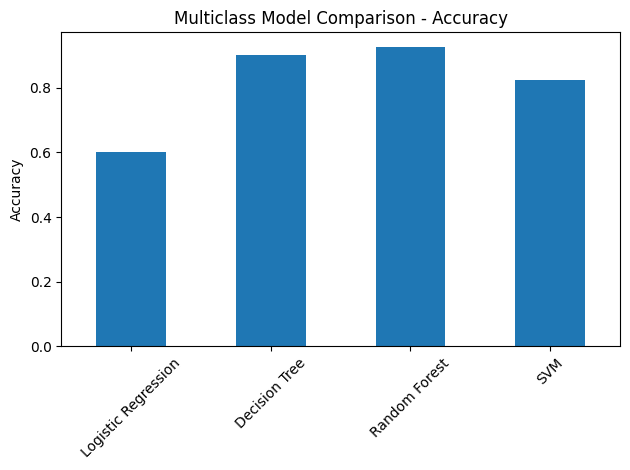

In [27]:
import matplotlib.pyplot as plt

plt.figure()
comparison_df["accuracy"].plot(kind="bar")
plt.title("Multiclass Model Comparison - Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Macro F1 Comparison

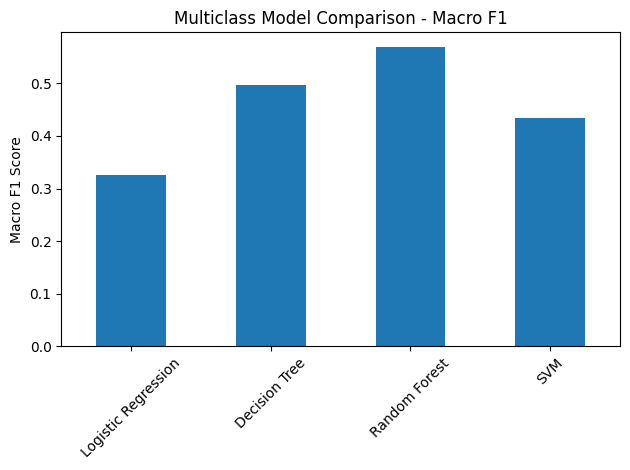

In [28]:
plt.figure()
comparison_df["macro_f1"].plot(kind="bar")
plt.title("Multiclass Model Comparison - Macro F1")
plt.ylabel("Macro F1 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Weighted F1 Comparison

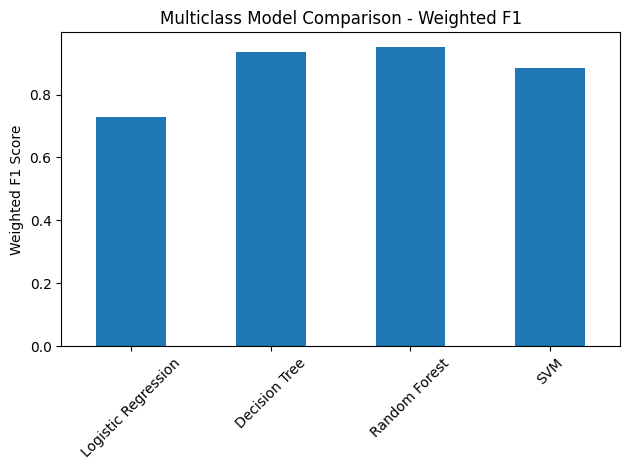

In [29]:
plt.figure()
comparison_df["weighted_f1"].plot(kind="bar")
plt.title("Multiclass Model Comparison - Weighted F1")
plt.ylabel("Weighted F1 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Multiclass ROC Curve

In [30]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities
rf_probs = rf_m.predict_proba(Xm_test)

# Binarize labels
classes = np.unique(ym_test)
ym_test_bin = label_binarize(ym_test, classes=classes)

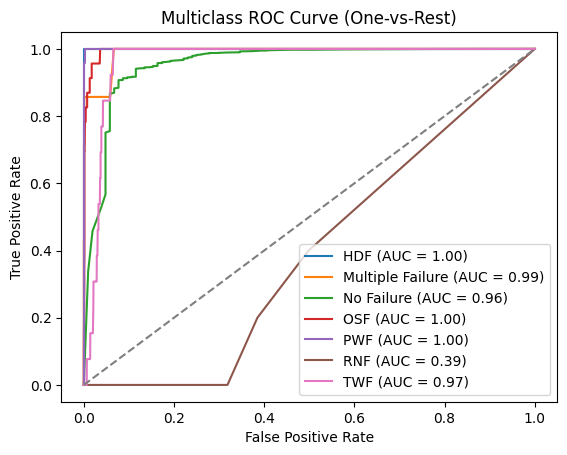

In [31]:
plt.figure()

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(ym_test_bin[:, i], rf_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

# Multiclass Confusion Matrix Heatmap

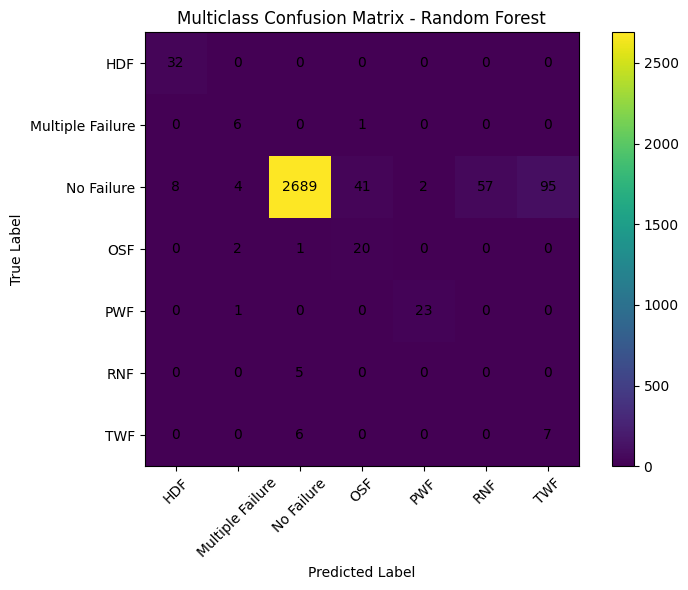

In [32]:
from sklearn.metrics import confusion_matrix

cm_multi = confusion_matrix(ym_test, rf_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm_multi)
plt.title("Multiclass Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm_multi.shape[0]):
    for j in range(cm_multi.shape[1]):
        plt.text(j, i, cm_multi[i, j],
                 ha="center", va="center")

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

plt.tight_layout()
plt.show()

# Best Model

In [33]:
best_model = comparison_df["macro_f1"].idxmax()
print("Best Multiclass Model based on Macro F1:", best_model)

Best Multiclass Model based on Macro F1: Random Forest


In [34]:
best_model = comparison_df["weighted_f1"].idxmax()
print("Best Multiclass Model based on Weighted F1:", best_model)

Best Multiclass Model based on Weighted F1: Random Forest


In [35]:
best_model = comparison_df["macro_f1"].idxmax()
best_score = comparison_df["macro_f1"].max()

print(f"Best Multiclass Model: {best_model}")
print(f"Macro F1 Score: {best_score:.4f}")

Best Multiclass Model: Random Forest
Macro F1 Score: 0.5687


# Save Model

In [38]:
import os
os.makedirs("artifacts", exist_ok=True)

joblib.dump(best_model, "../artifacts/best_model_multiclass.pkl")

print("Model saved successfully.")

Model saved successfully.
